In [1]:
%load_ext autoreload
%autoreload 1

import sys
sys.path.insert(0,'./supporting_code')
import os
import warnings
import time
import tqdm
%aimport helper_functions, produce_figures

from collections import defaultdict
import pandas as pd
import pickle
import numpy as np
import scipy
from pybiomart import Dataset

import seaborn as sns

In [2]:
# Defining file locations

# --------------------------------------------------------------------------- #
# NOTE: gencode.v44.primary_assembly.annotation.gtf has been preprocessed to 
# filter out only protein coding genes and saved as
# gencode_protein_coding_transcripts.csv
# 
# You can use the process_gtf_file function to process a new gencode file.
# promoter_df = helper_functions.process_gtf_file(gencode_file_path)
# --------------------------------------------------------------------------- #
# gencode_file_path = './supporting_data/gencode.v44.primary_assembly.annotation.gtf'

# protein coding genes file location
gencode_tss_path = './supporting_data/gencode_protein_coding_transcripts.csv'

# basenji dataset info
basenji_sequences_path = './basenji_human_data/sequences.bed'
basenji_targets_path = './basenji_human_data/targets.txt'

ground_truth_path = './supporting_data/ground_truth_CAGE_only.pickle'

# tissue categorization file location
tissue_path = './supporting_data/targets_with_subparts.csv'

# Ensembl gene names to ENSG file location
# Ensembl Genes 115, downloaded 2026-05-29
ensmble_gene_path = './supporting_data/ensg2gene_v115.csv'

# gene publication frequency file location
gene_prevalence_path = './supporting_data/gene_prevalence.tsv'

In [3]:
# Defining models and directories for analysis
models = ['Basenji','Enformer']

# NOTE: the data stored in these directories (ground truth and prediction
# .pickle files) are very large (~69GB each) and have not been released due to 
# size and cost, although they can be generated by running the inference scripts
# in the ./models/basenji and ./models/enformer subdirectories (see READMEs).
# Please contact the authors if you would like access to these files.

# Also note that these files are used for gene-based analyses, which covers
# sections 2.1-2.2.  In Section 2.3 below, we compare additional models using 
# track correlation, and more directories are defined.  These additional
# directories also corresponding .pickle files that have not been released.
model_dirs = {
    'Basenji': './models/basenji/released_model',
    'Enformer': './models/enformer/'
}

figure_output_dir = './figures'

# This cutoff is used to define On v. Off genes
cutoff = -0.5

In [4]:
# get columns corresponding to CAGE tracks from total set of basenji target
# outputs
CAGE_cols = helper_functions.extract_Basenji_CAGE_cols(basenji_targets_path)

# Load preprocessed gencode TSS
promoter_df = pd.read_csv(gencode_tss_path)

# get tss as indices of basenji tracks and mapping of genes to internal indices
# (for array access)
tss, gene_idx = helper_functions.locate_TSS_in_Basenji_tracks(promoter_df,basenji_sequences_path,'test')

 95%|█████████████████████████████████████████████████████████████████████▎   | 36245/38170 [00:00<00:00, 339348.92it/s]

Overlapping genes:
	 chr14 23289953 23404641 23306833.0 131 ENSG00000258643.6 [(131, 'ENSG00000129473.11')]
	 chr19 44337727 44452415 44401608.0 499 ENSG00000267508.6 [(499, 'ENSG00000267173.1')]
	 chr14 94511822 94626510 94561442.0 387 ENSG00000188488.14 [(387, 'ENSG00000100665.12')]
	 chr14 44851485 44966173 44962190.0 864 ENSG00000198718.13 [(864, 'ENSG00000179454.14')]
	 chr19 45599306 45713994 45602212.0 22 ENSG00000177464.5 [(22, 'ENSG00000125741.6')]
	 chr19 37685765 37800453 37719188.0 261 ENSG00000198182.13 [(261, 'ENSG00000267552.6')]
	 chr14 103228186 103342874 103334237.0 828 ENSG00000291313.1 [(828, 'ENSG00000100664.11')]
	 chr14 36479188 36593876 36521149.0 327 ENSG00000136352.20 [(327, 'ENSG00000257520.2')]
	 chr19 52671844 52786532 52690496.0 145 ENSG00000269825.3 [(145, 'ENSG00000167766.21')]
	 chr19 43993660 44108348 44025354.0 247 ENSG00000267022.1 [(247, 'ENSG00000159885.14')]
	 chr19 56811357 56926045 56840726.0 229 ENSG00000198300.14 [(229, 'ENSG00000269699.7')]
	

38171it [00:16, 2266.12it/s]                                                                                            


In [5]:
# loading in ground truth
# NOTE: this .pickle file is too large to upload to github (8.2GB) but is
# available at Hugging Face.  See README for download link to Hugging Face.
if not os.path.exists(ground_truth_path):
        raise FileNotFoundError(f"No such file or directory: {ground_truth_path}.\nNote that this .pickle file is very large (8.2GB) and has not been released to github due to size.  Please see the README for the Hugging Face link to download.")

with open(ground_truth_path,'rb') as f:
    gt = pickle.load(f)

# extract ground truth gene expression using tss
gene_exp_gt_raw = helper_functions.extract_gene_expression((len(gene_idx),len(CAGE_cols)),gene_idx,tss,gt)

In [6]:
# load in model outputs
# As noted above, model outputs are very large (~69GB each) and have not been
# released due to size and cost, although they can be generated by running the
# inference scripts in the ./models/basenji and ./models/enformer subdirectories
# (see READMEs).  Please contact the authors if you would like access to these
# files.
predictions = dict()
for model in models:
    print(f'Loading in {model} predictions')
    model_dir = model_dirs[model]
    
    if not os.path.exists(f'{model_dir}/model_best_test_set_pred.pickle'):
        raise FileNotFoundError(f"No such file or directory: {model_dir}/model_best_test_set_pred.pickle.\nNote that these .pickle files are very large (~69GB each) and have not been released due to size and cost.  They can be generated by running the inference scripts in the relevant directories (see README).  Please contact the authors if you would like access to these files.")
    
    with open(f'{model_dir}/model_best_test_set_pred.pickle','rb') as f:
        out = pickle.load(f)

    # pull out CAGE tracks only:
    out = out[:,:,CAGE_cols]
    
    # allocate results matrix based on genes and models
    gene_exp_pred_raw = helper_functions.extract_gene_expression((len(gene_idx),len(CAGE_cols)),gene_idx,tss,out)
    
    # normalize ground truth values according to Enformer's process
    # (log10(x+1) per track, then normalized to zero mean and unit variance)
    # and apply normalization to predictions
    ground_truth, gene_exp_pred = helper_functions.normalize(gene_exp_gt_raw,gene_exp_pred_raw)

    # store normalized predicted gene expression 
    predictions[model] = gene_exp_pred

Loading in Basenji predictions
Loading in Enformer predictions


# Section 2.1

## Generate data for plots

### Compute read counts of ON and OFF genes

In [7]:
on_genes = ground_truth > cutoff
print(f'Mean read count of "ON" genes: {np.mean(gene_exp_gt_raw[on_genes])}')
print(f'Mean read count of "OFF" genes: {np.mean(gene_exp_gt_raw[~on_genes])}')

Mean read count of "ON" genes: 141.8298902534441
Mean read count of "OFF" genes: 1.1735501435315576


### Generate synthetic distributions

In [8]:
distributions = ['Unimodal',
                 'Bimodal - overall track correlation',
                 'Bimodal - zero correlation']

In [9]:
np.random.seed(0)
synthetic_data = helper_functions.generate_synthetic_data(ground_truth,predictions['Enformer'],cutoff)

100%|████████████████████████████████████████████████████████████████████████████████| 638/638 [00:05<00:00, 127.26it/s]


### Generate scatter plot data

In [10]:
scatter_df = pd.DataFrame()
for model in models+distributions:
    if model in models:
        x = predictions[model]
        y = ground_truth
    else:
        x = synthetic_data[model]['x']
        y = synthetic_data[model]['y']
        
    df = helper_functions.estimate_distribution_density(x,y,model)
        
    scatter_df = pd.concat([scatter_df,df],ignore_index=True)

### Generate GMM dist v. correlation data

In [11]:
# GMM distances
GMM_dist = dict()

GMM_dist['Enformer'] = helper_functions.compute_GMM_dist(ground_truth)
GMM_dist['Basenji'] = GMM_dist['Enformer']

for dist in distributions:
    print(dist)
    GMM_dist[dist] = helper_functions.compute_GMM_dist(synthetic_data[dist]['y'])

# model correlations
track_corr = dict()
for model in models+distributions:
    if model in models:
        x = predictions[model]
        y = ground_truth
    else:
        x = synthetic_data[model]['x']
        y = synthetic_data[model]['y']
    track_corr[model] = helper_functions.compute_per_track_corr(np.expand_dims(y,axis=1),np.expand_dims(x,axis=1))

100%|█████████████████████████████████████████████████████████████████████████████████| 638/638 [00:19<00:00, 32.86it/s]


Unimodal


100%|█████████████████████████████████████████████████████████████████████████████████| 638/638 [00:17<00:00, 36.52it/s]


Bimodal - overall track correlation


100%|█████████████████████████████████████████████████████████████████████████████████| 638/638 [00:15<00:00, 40.94it/s]


Bimodal - zero correlation


100%|██████████████████████████████████████████████████████████████████████████████| 638/638 [00:00<00:00, 54347.58it/s]


### Generate running "On"/"Off" correlation data

In [12]:
low = np.floor(np.min(ground_truth)*100)/100
high = np.ceil(np.max(ground_truth)*100)/100
num = np.round((high-low)*100)+1

cutoff_interp = np.linspace(low,high,endpoint=True,num = int(num))

df_ON = pd.DataFrame()
df_OFF = pd.DataFrame()

for model in models+distributions:
    if model in models:
        x = ground_truth
        y = predictions[model]
    else:
        x = synthetic_data[model]['x']
        y = synthetic_data[model]['y']
        
    model_ON, model_OFF = helper_functions.generate_running_correlation_dataframes(model,x,y,cutoff_interp)

    df_ON = pd.concat([df_ON,model_ON], ignore_index = True)
    df_OFF = pd.concat([df_OFF,model_OFF], ignore_index = True)

    if model in models: # add the random sampling for Basenji and Enformer
        random_ON, random_OFF = helper_functions.generate_randomly_sampled_running_correlation_dataframes(model,ground_truth,predictions[model],cutoff_interp,model_ON,model_OFF)

        df_ON = pd.concat([df_ON,random_ON], ignore_index = True)
        df_OFF = pd.concat([df_OFF,random_OFF], ignore_index = True)
        

/disk1/ada/Replicability_paper/supporting_code/helper_functions.py:53: RuntimeWarning: invalid value encountered in sqrt
  correlation = np.divide(covariance, np.sqrt(true_var * pred_var))
/disk1/ada/Replicability_paper/supporting_code/helper_functions.py:53: RuntimeWarning: divide by zero encountered in divide
  correlation = np.divide(covariance, np.sqrt(true_var * pred_var))
100%|█████████████████████████████████████████████████████████████████████████████████| 638/638 [01:39<00:00,  6.44it/s]
/disk1/ada/Replicability_paper/supporting_code/helper_functions.py:53: RuntimeWarning: invalid value encountered in divide
  correlation = np.divide(covariance, np.sqrt(true_var * pred_var))
/disk1/ada/Replicability_paper/supporting_code/helper_functions.py:53: RuntimeWarning: divide by zero encountered in divide
  correlation = np.divide(covariance, np.sqrt(true_var * pred_var))
100%|█████████████████████████████████████████████████████████████████████████████████| 638/638 [01:25<00:00,  7.47

## Set paper-wide color scheme

In [13]:
scatter_cmap = sns.color_palette("blend:#466e8c,#EDA", as_cmap=True)

model_colors = {
    'Basenji': sns.color_palette('Set2')[1],
    'Enformer': sns.color_palette('Set2')[2],
}
for dist,i in zip(distributions, [0,3,4]):
    model_colors[dist] = sns.color_palette('Set2')[i]

## Figure 1

Correlation of "On" genes: 0.5270176893089537
Correlation of "Off" genes: 0.5320314113819183
Correlation of "On" genes: 0.6414222248251653
Correlation of "Off" genes: 0.5328598141068516


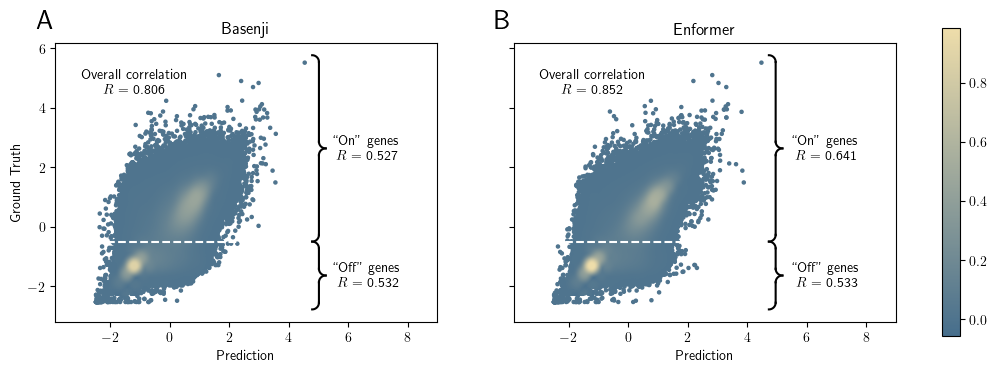

In [14]:
produce_figures.figure_1(models,scatter_df,scatter_cmap,cutoff,f'{figure_output_dir}/1_predicted_vs_gt_scatter.pdf')

## Figure 2

In [15]:
# generate running correlations for random subsets of genes to assess effect of small sample size
for random_model in df_ON['Model'][df_ON['Model'].str.contains('random', na=False)].unique():
    for model in models:
        if model in random_model:
            model_colors[random_model] = model_colors[model]
            break

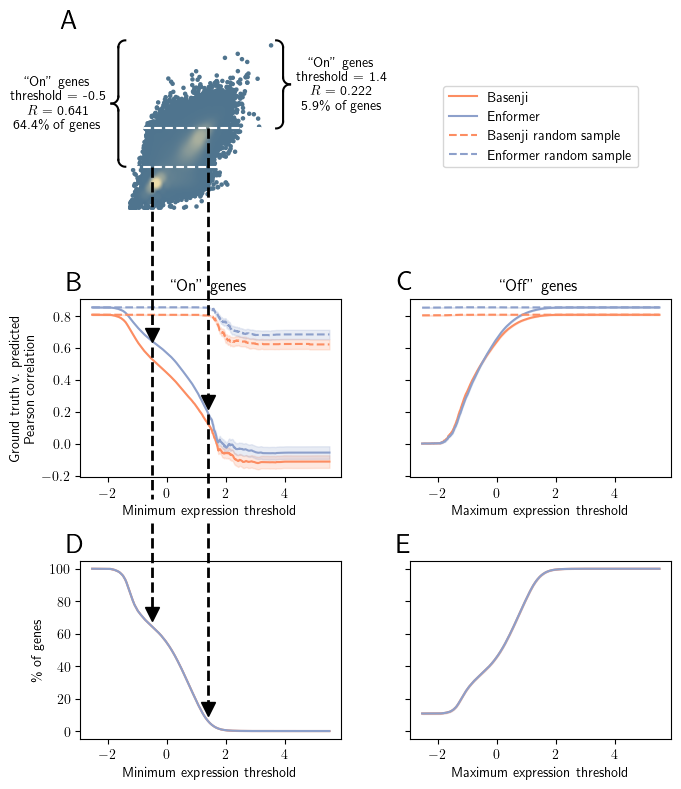

In [16]:
enformer_scatter = scatter_df[scatter_df['Model'] == 'Enformer']
produce_figures.figure_2(models,enformer_scatter,df_ON,df_OFF,'se',scatter_cmap,model_colors,f'{figure_output_dir}/2_running_correlation.pdf')

## Figure 3

In [17]:
random_rows = df_ON['Model'].str.contains('random',na=False)
df_ON_models = df_ON[~random_rows]
df_OFF_models = df_OFF[~random_rows]

Overall model performance (Pearson correlation):
	Basenji: 0.806
	Enformer: 0.852
	Unimodal: 0.852
	Bimodal - overall track correlation: 0.960
	Bimodal - zero correlation: 0.742
GMM to Pearson correlations:
	Basenji:
		Correlation = 0.577, p = 6.57e-58
		Correlation = 0.553, p = 1.59e-50 (Excluding top/bottom 1% distance and corr)
	Enformer:
		Correlation = 0.567, p = 1.96e-55
		Correlation = 0.540, p = 7.42e-48 (Excluding top/bottom 1% distance and corr)
	Unimodal:
		Correlation = 0.100, p = 1.17e-02
		Correlation = 0.117, p = 3.78e-03 (Excluding top/bottom 1% distance and corr)
	Bimodal - overall track correlation:
		Correlation = 0.780, p = 2.28e-131
		Correlation = 0.771, p = 9.49e-123 (Excluding top/bottom 1% distance and corr)
	Bimodal - zero correlation:
		Correlation = 0.848, p = 1.53e-177
		Correlation = 0.844, p = 2.64e-168 (Excluding top/bottom 1% distance and corr)


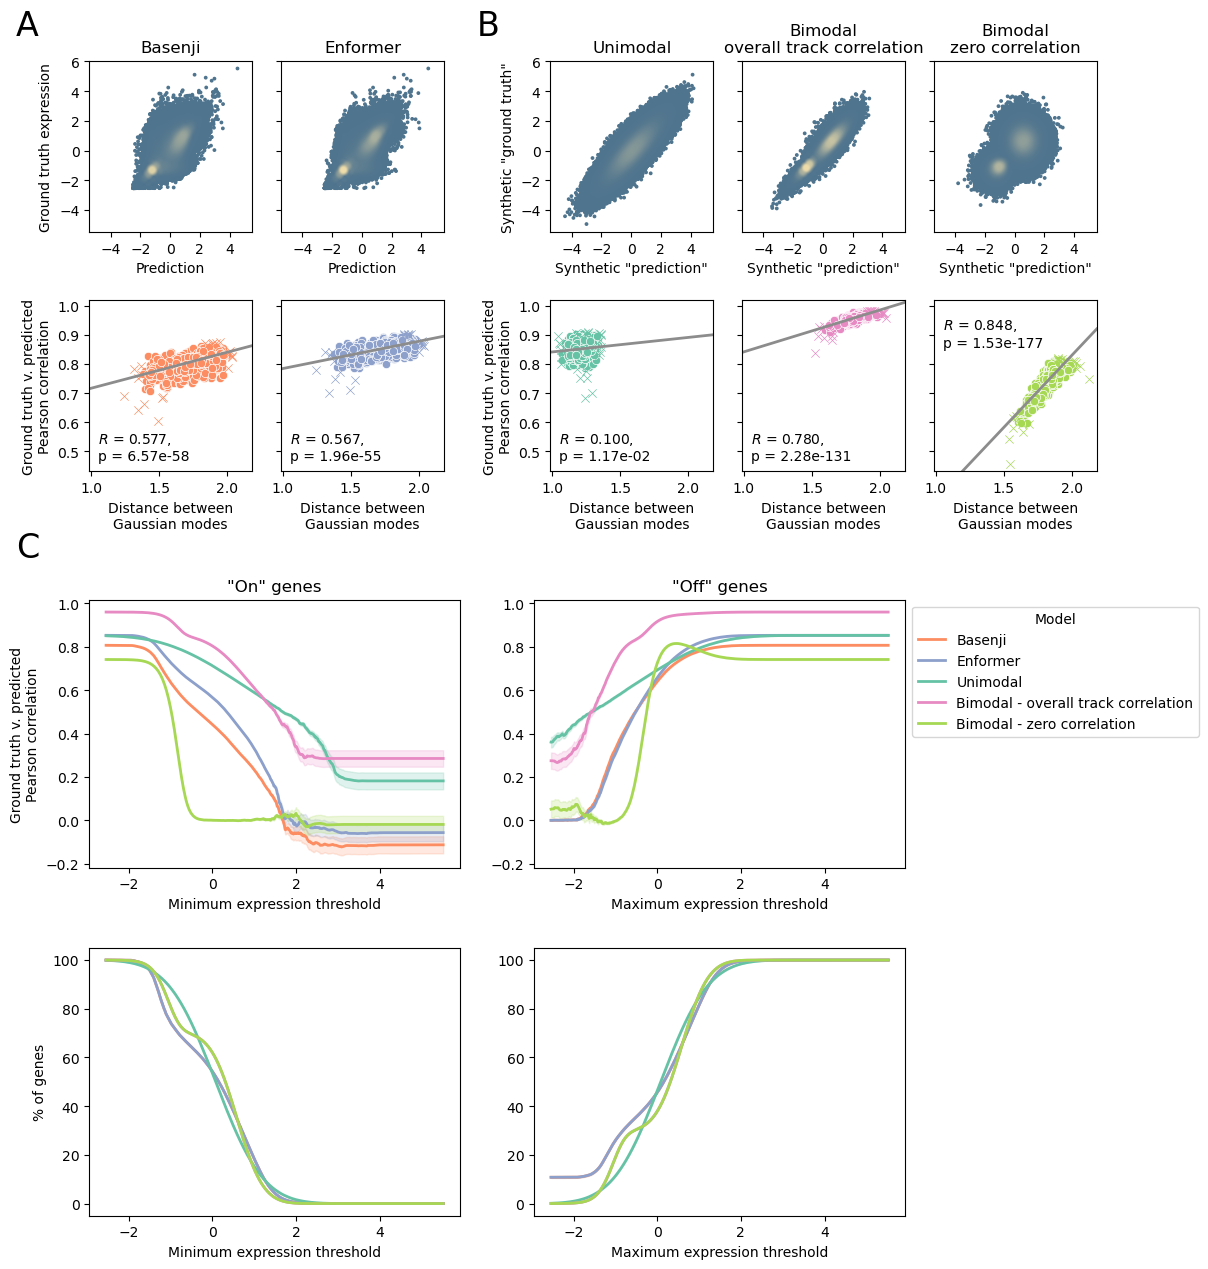

In [18]:
produce_figures.figure_3(models+distributions,scatter_df,GMM_dist,track_corr,df_ON_models,df_OFF_models,'se',scatter_cmap,model_colors,f'{figure_output_dir}/3_synthetic_comparison.pdf')

## Tissue-based GMM analysis and ANOVA

In [19]:
# load tissue categorization
tissue_df = pd.read_csv(tissue_path)

# remove extra rows
tissue_df = tissue_df[['index','Tissue','Cancer']]

# fill NaN to be N/A
tissue_df['Tissue'] = tissue_df['Tissue'].fillna('N/A')

# add correlations and distances to tissue dataframe
tissue_df['Distance'] = GMM_dist['Basenji'] # was set equal to GMM_dist['Enformer']
tissue_df['Basenji'] = track_corr['Basenji']
tissue_df['Enformer'] = track_corr['Enformer']

### Tissue fig (Supplemental S1)

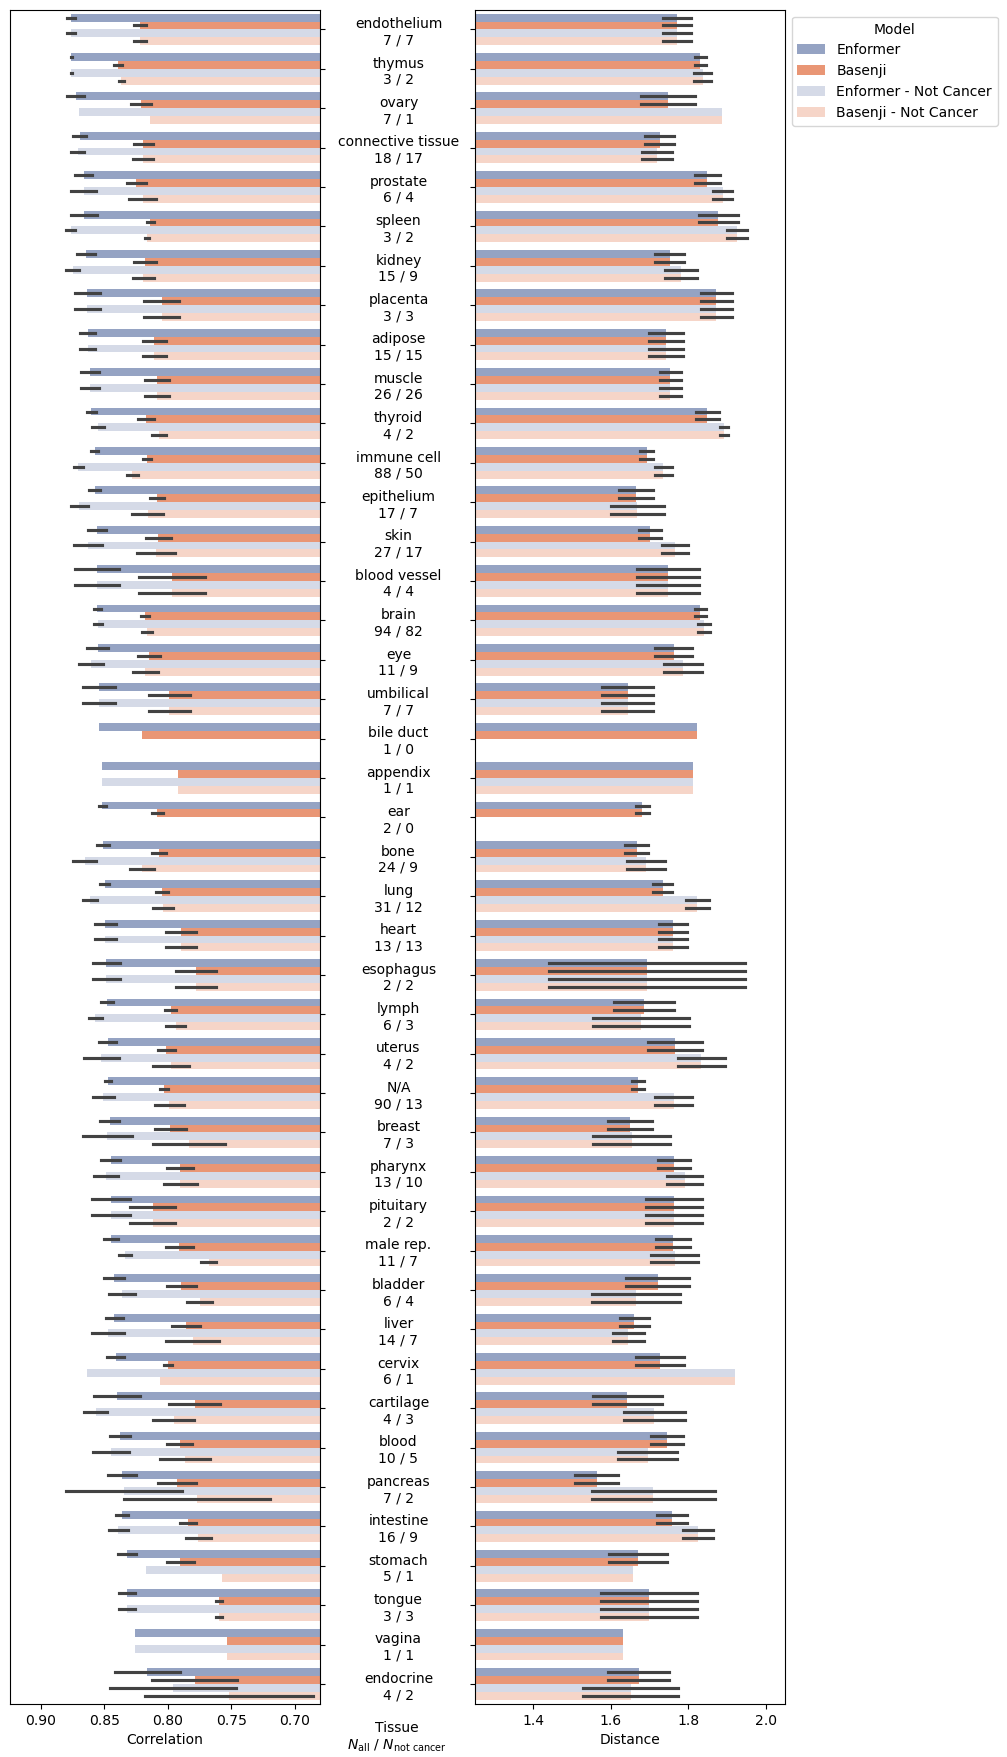

In [20]:
produce_figures.figure_S1(tissue_df,model_colors,f'{figure_output_dir}/S1_perf_by_tissue.pdf')

### Table S1: ANOVA 

In [21]:
# remove N/A tissues
tissue_df = tissue_df[tissue_df['Tissue']!='N/A']

# ANOVA including cancer cells
temp_df = tissue_df.groupby('Tissue').filter(lambda x: len(x) >= 3) # remove tissues with fewer than 3 samples
for model in ['Basenji','Enformer']:
    tissue_corr = []
    for t in temp_df['Tissue'].unique():
        tissue_rows = (temp_df['Tissue'] == t)
        tissue_corr.append(np.array(temp_df[tissue_rows][model]))
    f_statistic, p_value = scipy.stats.f_oneway(*tissue_corr)
    print(f'{model} ANOVA test on Tissue v. Correlation:')
    print(f"\tF-statistic: {f_statistic}")
    print(f"\tP-value: {p_value}")

tissue_dist = []
for t in temp_df['Tissue'].unique():
    tissue_rows = (temp_df['Tissue'] == t)
    tissue_dist.append(np.array(temp_df[tissue_rows]['Distance']))
f_statistic, p_value = scipy.stats.f_oneway(*tissue_dist)
print(f'ANOVA test on Tissue v. Distance:')
print(f"\tF-statistic: {f_statistic}")
print(f"\tP-value: {p_value}")

# ANOVA excluding cancer cells
temp_df = tissue_df[tissue_df['Cancer'] == 'No'] # select out tissues that were NOT cancer
temp_df = temp_df.groupby('Tissue').filter(lambda x: len(x) >= 3) # remove tissues with fewer than 3 samples
for model in ['Basenji','Enformer']:
    tissue_corr = []
    for t in temp_df['Tissue'].unique():
        tissue_rows = (temp_df['Tissue'] == t)
        tissue_corr.append(np.array(temp_df[tissue_rows][model]))
    f_statistic, p_value = scipy.stats.f_oneway(*tissue_corr)
    print(f'{model} ANOVA test on Tissue v. Correlation (without cancer):')
    print(f"\tF-statistic: {f_statistic}")
    print(f"\tP-value: {p_value}")

tissue_dist = []
for t in temp_df['Tissue'].unique():
    tissue_rows = (temp_df['Tissue'] == t)
    tissue_dist.append(np.array(temp_df[tissue_rows]['Distance']))
f_statistic, p_value = scipy.stats.f_oneway(*tissue_dist)
print(f'ANOVA test on Tissue v. Distance (without cancer):')
print(f"\tF-statistic: {f_statistic}")
print(f"\tP-value: {p_value}")

Basenji ANOVA test on Tissue v. Correlation:
	F-statistic: 2.065422774865687
	P-value: 0.00043325538240515774
Enformer ANOVA test on Tissue v. Correlation:
	F-statistic: 1.9973342358702897
	P-value: 0.0007768006426062623
ANOVA test on Tissue v. Distance:
	F-statistic: 2.636602069008416
	P-value: 2.222628054320781e-06
Basenji ANOVA test on Tissue v. Correlation (without cancer):
	F-statistic: 2.3806041950424714
	P-value: 0.00025459769465183845
Enformer ANOVA test on Tissue v. Correlation (without cancer):
	F-statistic: 1.6851590883102912
	P-value: 0.021433665583671165
ANOVA test on Tissue v. Distance (without cancer):
	F-statistic: 2.1855366106563516
	P-value: 0.0009543738144585053


### Tissue-based GMM (Supplemental S2)

In [22]:
tissue_GMM = defaultdict(list)
tissue_GMM_2 = defaultdict(list)
tissue_corr = defaultdict(list)
tissue_corr_2 = defaultdict(list)
mc = dict()
temp_df = tissue_df.groupby('Tissue').filter(lambda x: len(x) >= 3) # remove tissues with fewer than 3 samples
for model in ['Basenji','Enformer']:
    for t in tqdm.tqdm(temp_df['Tissue'].unique()):
        tissue_rows = (temp_df['Tissue'] == t)
        tissue_corr[model].append(np.mean(np.array(temp_df[tissue_rows][model])))
        tissue_GMM[model].append(np.mean(np.array(temp_df[tissue_rows]['Distance'])))

        tissue_indices = temp_df[tissue_rows].index
        tissue_dist_gt = np.expand_dims(ground_truth[:,tissue_indices].flatten(),axis=1)
        tissue_dist_pred = np.expand_dims(predictions[model][:,tissue_indices].flatten(),axis=1)
        tissue_GMM_2[model].append(helper_functions.compute_GMM_dist(tissue_dist_gt,True)[0])
        tissue_corr_2[model].append(helper_functions.fast_pearson(tissue_dist_gt,tissue_dist_pred))
    mc[model] = model_colors[model]


temp_df = tissue_df[tissue_df['Cancer'] == 'No'] # select out tissues that were NOT cancer
temp_df = temp_df.groupby('Tissue').filter(lambda x: len(x) >= 3) # remove tissues with fewer than 3 samples
for model in ['Basenji','Enformer']:
    for t in tqdm.tqdm(temp_df['Tissue'].unique()):
        tissue_rows = (temp_df['Tissue'] == t)
        tissue_corr[f'{model} no cancer'].append(np.mean(np.array(temp_df[tissue_rows][model])))
        tissue_GMM[f'{model} no cancer'].append(np.mean(np.array(temp_df[tissue_rows]['Distance'])))
        
        tissue_indices = temp_df[tissue_rows].index
        tissue_dist_gt = np.expand_dims(ground_truth[:,tissue_indices].flatten(),axis=1)
        tissue_dist_pred = np.expand_dims(predictions[model][:,tissue_indices].flatten(),axis=1)
        tissue_GMM_2[f'{model} no cancer'].append(helper_functions.compute_GMM_dist(tissue_dist_gt,True)[0])
        tissue_corr_2[f'{model} no cancer'].append(helper_functions.fast_pearson(tissue_dist_gt,tissue_dist_pred))
    mc[f'{model} no cancer'] = model_colors[model]

100%|███████████████████████████████████████████████████████████████████████████████████| 27/27 [00:07<00:00,  3.59it/s]


Method: Average GMM distance:
	Basenji:
		Correlation = 0.501, p = 1.85e-03
	Enformer:
		Correlation = 0.542, p = 6.39e-04
	Basenji no cancer:
		Correlation = 0.308, p = 1.18e-01
	Enformer no cancer:
		Correlation = 0.229, p = 2.50e-01
Method: Collate ground truth then compute new GMM:
	Basenji:
		Correlation = 0.461, p = 4.61e-03
	Enformer:
		Correlation = 0.485, p = 2.69e-03
	Basenji no cancer:
		Correlation = 0.408, p = 3.46e-02
	Enformer no cancer:
		Correlation = 0.367, p = 6.01e-02


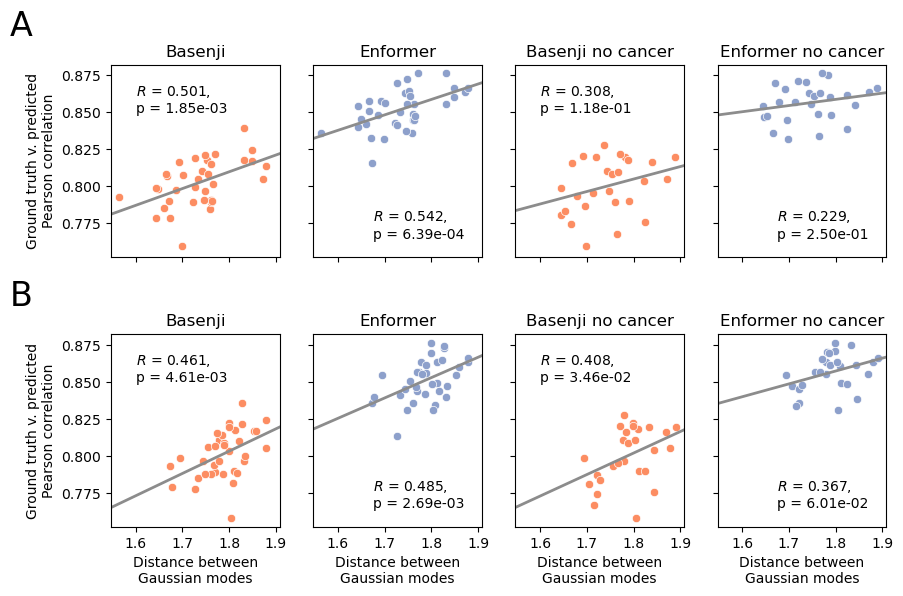

In [23]:
produce_figures.figure_S2(tissue_corr, tissue_GMM, tissue_corr_2, tissue_GMM_2, mc, f'{figure_output_dir}/S2_corr_v_GMM_by_tissue.pdf')

## Figure 4

### Naive model example

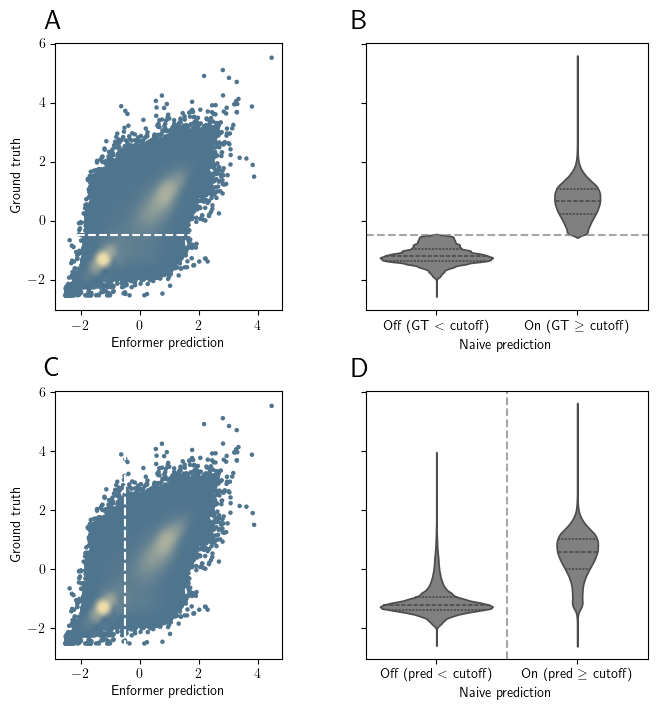

In [24]:
produce_figures.figure_S3(ground_truth,predictions['Enformer'],-0.5,-0.5,scatter_cmap,f'{figure_output_dir}/S3_naive_model_example.pdf')

### Figure 4 - comparing continuous model and naive (binary) model correlation to ground truth

In [25]:
results = []
for model in ['Basenji','Enformer']:
    res = helper_functions.compute_naive_corr(model,ground_truth,predictions[model],-0.5,-0.5)
    results.append(res)
    
for dist in distributions:
    res = helper_functions.compute_naive_corr(dist,synthetic_data[dist]['y'],synthetic_data[dist]['x'],-0.5,-0.5)
    results.append(res)

corr_df = pd.concat([pd.DataFrame(r) for r in results], ignore_index=True)

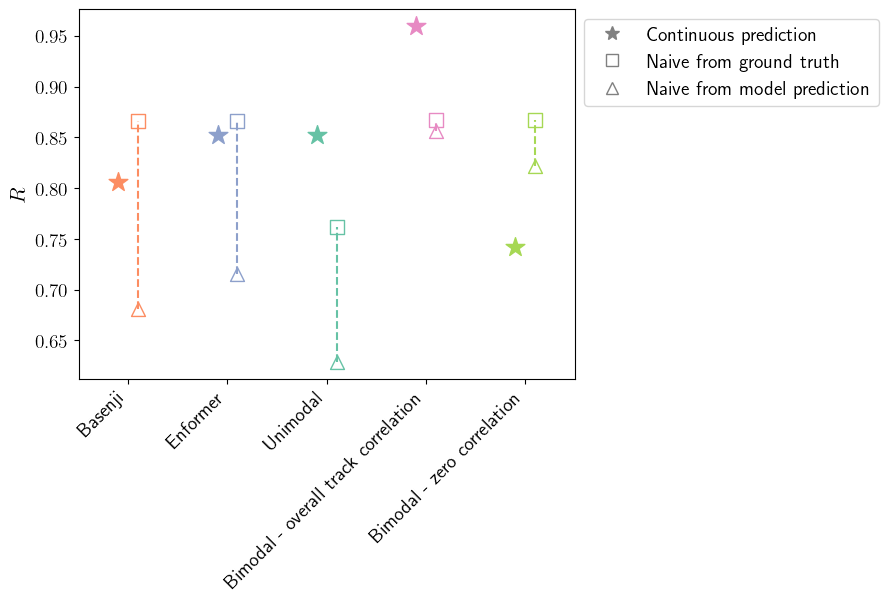

In [26]:
produce_figures.figure_4(corr_df,model_colors,f'{figure_output_dir}/4_naive_comparison.pdf')

# Section 2.2 - Disease focused performance analysis

## GSEA analysis

In [27]:
# Reloading tissues because N/A tissues were removed for Table S1 ANOVA above.
# load tissue categorization
tissue_df = pd.read_csv(tissue_path)

# remove extra rows
tissue_df = tissue_df[['index','Tissue','Cancer']]

# fill NaN to be N/A
tissue_df['Tissue'] = tissue_df['Tissue'].fillna('N/A')

### Generate data for GSEA analysis

In [28]:
# This function generates numpy runtime warnings because not all tissues have
# cancerous and non-cancerous samples, so some groups have 0 samples, and
# numpy throws warnings for trying to take the median of those size-0 groups
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    helper_functions.generate_normalized_absolute_error_medians(ground_truth, predictions, tissue_df, list(gene_idx.keys()))

### Analyze OR gene expression

In [29]:
# clean version number from gene IDs
ensg = []
for x in gene_idx:
    ensg.append(x.split('.')[0])

# import ensembl gene names and mapping to ENSG
try:
    ensg2gene = pd.read_csv(ensmble_gene_path)
except (FileNotFoundError, NameError):
    # These lines were used to save the csv file being loaded in the try block
    # The file name was manually edited to reflect the ensembl version on the 
    # download date (May 29, 2026)
    
    # NOTE: sometimes ensembl goes down, in that case, try uswest.ensemble.org or
    # useast.ensembl.org instead of www.ensembl.org
    # ADDITIONAL NOTE: sometimes ensembl load fails and you need to try rerunning this cell
    dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')
    ensg2gene = dataset.query(attributes=['ensembl_gene_id', 'external_gene_name'])
    ensg2gene.to_csv('./supporting_data/ensg2gene.csv',index=False)

# Grab genes with names starting with OR
OR_genes = ensg2gene[ensg2gene['Gene stable ID'].isin(ensg) & ensg2gene['Gene name'].str.match(r'^OR\d')]

# Grab corresponding ENSG and remove potential duplicates
OR_ensg = set(OR_genes['Gene stable ID'])

# Convert to internal gene index for indexing into matrices
OR_gene_idx = []
for (ensg,i) in gene_idx.items():
    ensg = ensg.split('.')[0]

    if ensg in OR_ensg:
        OR_gene_idx.append(i)

# grab cancerous CAGE tracks
cancer_CAGE = tissue_df[tissue_df['Cancer'] == 'Yes'].index.to_numpy()

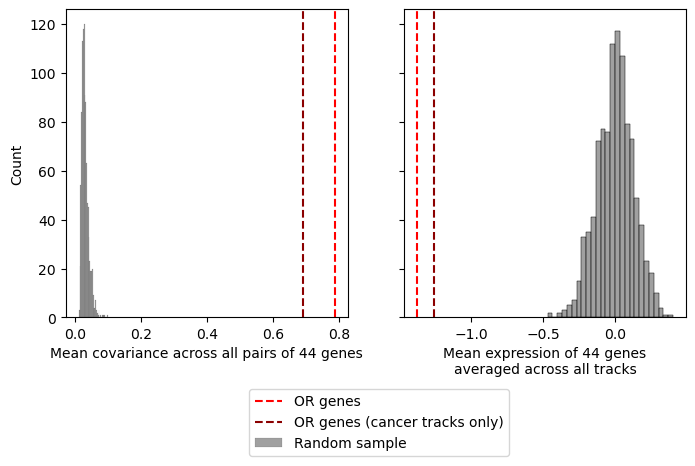

In [30]:
produce_figures.figure_S4(ground_truth, OR_gene_idx, cancer_CAGE, 1000, f'{figure_output_dir}/S4_OR_gene_exp_and_cov.pdf')

## Prediction performance vs. publication frequency

In [31]:
# get gene publication frequency for genes in our analysis (Basenji's test set)
gene_prevalence_df = pd.read_csv(gene_prevalence_path,sep='\t')

pub_freq = []
for ensg,idx in gene_idx.items():
    count = gene_prevalence_df.loc[gene_prevalence_df['EnsemblID'] == ensg.split('.')[0], 'count']
    pub_freq.append(count.sum())
pub_freq = np.array(pub_freq)

# get model correlation per gene
gene_corr = dict()
for model in models:
    gene_corr[model] = helper_functions.compute_per_track_corr(np.expand_dims(ground_truth.T,axis=1),np.expand_dims(predictions[model].T,axis=1))

100%|████████████████████████████████████████████████████████████████████████████| 1955/1955 [00:00<00:00, 79783.84it/s]


77 genes excluded from analysis for having 0 publications
Enformer: Pearson R = 0.0481, p = 0.0371
Basenji: Pearson R = 0.0067, p = 0.7711


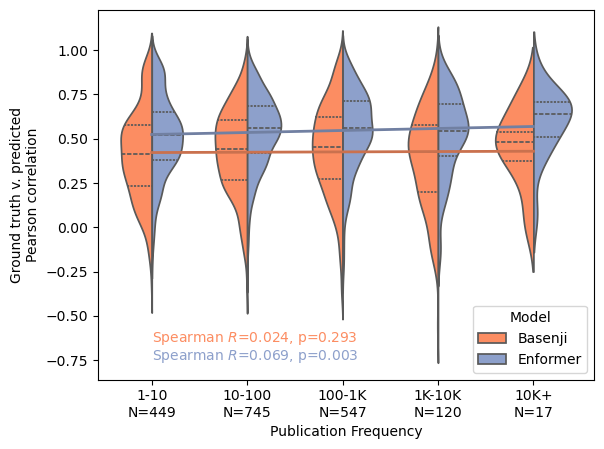

In [32]:
produce_figures.figure_5(pub_freq,gene_corr,model_colors,f'{figure_output_dir}/5_performance_v_pub_freq.pdf')

# Section 2.3 - Model performance reproducibility

In [33]:
# manually add in reported performance
model_perf_df = pd.DataFrame(columns=['Model', 'Correlation'])
model_perf_df.loc[0] = ['Enformer reported', 0.712]
model_perf_df.loc[1] = ['Basenji human & mouse trained reported', 0.645]
model_perf_df.loc[2] = ['Basenji human trained reported', 0.632]

# models to compare
reproducibility_model_dirs = []
reproducibility_model_dirs.append('./models/enformer')
reproducibility_model_dirs.append('./models/basenji/released_model')

models = ['Enformer released','Basenji released']

for augmentation in ['original','augmented']:
    for run in range(1,5):
        reproducibility_model_dirs.append(f'./models/basenji/{augmentation}/run_{run}')
        if augmentation == 'original':
            models.append('Basenji retrained')
        else:
            models.append('Basenji retrained with augmentation')

# loading in ground truth
with open(ground_truth_path,'rb') as f:
    gt = pickle.load(f)

# --------------------------------------------------------------------------- #
# NOTE: these .pickle files are very large (~69GB each) and have not been
# released due to size and cost, although they can be generated by running the
# inference scripts in the ./models/basenji and ./models/enformer subdirectories
# (see READMEs).  Please contact the authors if you would like access to these
# files.
# --------------------------------------------------------------------------- #
all_corr = []
for d in reproducibility_model_dirs:
    filename = f'{d}/model_best_test_set_pred.pickle'
    print(f'Loading in {d}')
    
    if not os.path.exists(filename):
        raise FileNotFoundError(f"No such file or directory: {model_dir}/model_best_test_set_pred.pickle.\nNote that these .pickle files are very large (~69GB each) and have not been released due to size and cost.  They can be generated by running the inference scripts in the relevant directories (see README).  Please contact the authors if you would like access to these files.")
    
    with open(filename,'rb') as f:
        out = pickle.load(f)

    if out.shape != gt.shape:
        out = out[:,:,CAGE_cols]
        
    corr = helper_functions.compute_per_track_corr(out,gt)
    print(f'\tMean across-track correlation: {np.mean(corr):.3f}')
    all_corr.append(np.mean(corr))

# append released and retrained model performance to dataframe of reported
# performance
model_perf_df = pd.concat([model_perf_df,pd.DataFrame({'Model':models,'Correlation':all_corr})],ignore_index=True)

# move "Enformer released" to be right after "Enformer reported"
model_perf_df = model_perf_df.reindex([0, 3, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12]).reset_index(drop=True)

Loading in ./models/enformer


100%|█████████████████████████████████████████████████████████████████████████████████| 638/638 [00:41<00:00, 15.37it/s]


	Mean across-track correlation: 0.711
Loading in ./models/basenji/released_model


100%|█████████████████████████████████████████████████████████████████████████████████| 638/638 [00:34<00:00, 18.24it/s]


	Mean across-track correlation: 0.626
Loading in ./models/basenji/original/run_1


...

	Mean across-track correlation: 0.607
Loading in ./models/basenji/augmented/run_3


100%|█████████████████████████████████████████████████████████████████████████████████| 638/638 [00:34<00:00, 18.41it/s]


	Mean across-track correlation: 0.603
Loading in ./models/basenji/augmented/run_4


100%|█████████████████████████████████████████████████████████████████████████████████| 638/638 [00:44<00:00, 14.35it/s]

	Mean across-track correlation: 0.618


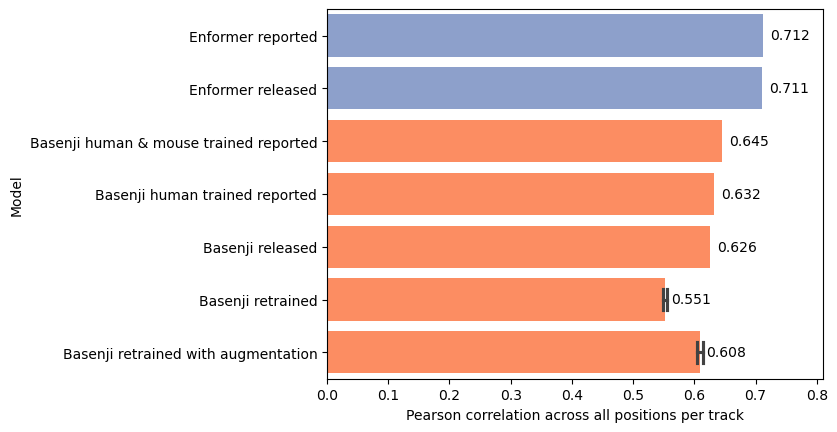

In [34]:
produce_figures.figure_6(model_perf_df,model_colors,f'{figure_output_dir}/6_model_comparison.pdf')